# MPDOK — RBF Spatial Interpolation Demo

**Problem**: reconstruct continuous multi-field maps from sparse sensor readings  
**Solver**: MPDOK mixed-precision iterative refinement (FP64 accuracy, TF32 tensor-core speed)  
**Hardware**: NVIDIA RTX 4060 (8.2 GB VRAM, Ampere cc8.9)

---

### The setup

$N = 8{,}192$ irregularly-spaced sensors across a 100×100 km region each track three independent physical fields: **temperature**, **atmospheric pressure**, and **humidity**.

Reconstructing any field at an arbitrary location requires solving the RBF interpolation system:

$$A\,\mathbf{x} = \mathbf{b}, \qquad A_{ij} = \exp\!\left(-\gamma\,\|p_i - p_j\|^2\right) + \delta_{ij}\,\sigma^2$$

**Key insight**: $A$ depends only on sensor *geometry*, not on the field values. When the sensor layout is fixed — which it is in every realistic deployment — $A$ needs to be built and factored only **once**. All three fields at all 24 time steps share the same $A$.

This is exactly the scenario where **LU-IR** dominates: pay the $O(N^3)$ factorization cost once using tensor-core FP32/TF32, then solve each new right-hand side in $O(N^2)$ with FP64 iterative refinement.

In [4]:
import sys, os
import cupy  as cp
import numpy as np
import scipy.linalg
import sys, os, time, warnings, gc

# All modules are in the same folder as this notebook.
_here = os.path.abspath('')
if _here not in sys.path:
    sys.path.insert(0, _here)

from mpdok_ops import MPDOKSolver, LUIRSolver
from sensor_field import SensorNetwork, FIELDS

# ── Config ────────────────────────────────────────────────────────────
N       = 8_192
REG     = 1e-2      # cond ≈ N/REG = 8.2e5
T_STEPS = 24
TOL     = 1e-5

# ── GPU info ──────────────────────────────────────────────────────────
props   = cp.cuda.runtime.getDeviceProperties(0)
vram_gb = props['totalGlobalMem'] / 1e9
free_gb = cp.cuda.runtime.memGetInfo()[0] / 1e9
print(f"GPU  : {props['name'].decode()}")
print(f"VRAM : {vram_gb:.1f} GB total  /  {free_gb:.1f} GB free")
print(f"N    : {N:,}   REG={REG:.0e}   T={T_STEPS} steps   fields={list(FIELDS)}")

GPU  : NVIDIA GeForce RTX 4060
VRAM : 8.2 GB total  /  7.1 GB free
N    : 8,192   REG=1e-02   T=24 steps   fields=['temperature', 'pressure', 'humidity']


---
## §1  Building the Shared Kernel Matrix

The $N \times N$ RBF matrix $A$ is constructed entirely on the GPU using the GEMM identity for pairwise distances:

$$\|p_i - p_j\|^2 = \|p_i\|^2 + \|p_j\|^2 - 2\,p_i \cdot p_j$$

The right-hand term is a single cuBLAS DGEMM; the squared-norm terms are broadcasted row-vectors. No $N \times N \times D$ intermediate tensor is ever formed. Rows are computed in 1024-row chunks so peak extra VRAM is ~256 MB regardless of $N$.

In [5]:
net = SensorNetwork(N=N, seed=42, reg=REG)

t0 = time.perf_counter()
A, gamma = net.build_kernel()
t_build = time.perf_counter() - t0
cp.cuda.Stream.null.synchronize()

free_after = cp.cuda.runtime.memGetInfo()[0] / 1e9
vram_A     = N**2 * 8 / 1e9
cond_est   = N / REG
fp32_floor = cond_est * 1.2e-7   # eps_fp32 × cond

print(f"Kernel build : {t_build:.2f} s")
print(f"A shape      : {A.shape}  dtype={A.dtype}  order={'F' if A.flags['F_CONTIGUOUS'] else 'C'}")
print(f"A in VRAM    : {vram_A:.2f} GB   (free now: {free_after:.1f} GB)")
print(f"gamma        : {gamma:.4e}")
print(f"cond(A) ≈    : {cond_est:.1e}   (N / reg)")
print(f"FP32 floor   : {fp32_floor:.1e}   (eps_fp32 × cond)  — GMRES-IR beats this")

Kernel build : 0.18 s
A shape      : (8192, 8192)  dtype=float64  order=F
A in VRAM    : 0.54 GB   (free now: 6.2 GB)
gamma        : 1.5053e-04
cond(A) ≈    : 8.2e+05   (N / reg)
FP32 floor   : 9.8e-02   (eps_fp32 × cond)  — GMRES-IR beats this


---
## §2  Phase 1 — Single-Field Solve

Benchmark three approaches for a **single** solve of $A\mathbf{x} = \mathbf{b}$ (temperature field at $t=0$):

| Solver | Backend | Precision | Expected bottleneck |
|--------|---------|-----------|---------------------|
| `scipy.linalg.solve` | CPU LAPACK | FP64 | Memory bandwidth + no GPU |
| `cp.linalg.solve` | cuSOLVER FP64 LU | FP64 | $O(N^3)$ direct LU, no tensor cores |
| **MPDOK GMRES-IR** | Fortran + cuBLAS | **FP64 acc. / TF32 speed** | Inner Krylov in FP32/TF32, outer residual in FP64 |

The **precision floor** argument: a pure FP32 solver would stall at `rel_res ≈ eps_fp32 × cond(A) ≈ 1e-1`. GMRES-IR pushes past the FP32 ceiling by correcting the solution in FP64 after each inner Krylov cycle.

In [6]:
b0      = net.field('temperature', t=0)
b0_np   = cp.asnumpy(b0)
A_np    = cp.asnumpy(A)           # host copy for SciPy (transferred once for fair timing)
results = {}

# ── 1a. SciPy direct LU (CPU) ─────────────────────────────────────────
t0 = time.perf_counter()
x_scipy = scipy.linalg.solve(A_np, b0_np)
t_scipy = time.perf_counter() - t0
rr_scipy = float(np.linalg.norm(b0_np - A_np @ x_scipy) / np.linalg.norm(b0_np))
results['SciPy  direct LU  (CPU)'] = (t_scipy, rr_scipy)
print(f"SciPy  direct LU  (CPU)   : {t_scipy*1e3:7.1f} ms   rel_res={rr_scipy:.2e}")

# ── 1b. CuPy direct LU (GPU, FP64) ───────────────────────────────────
cp.cuda.Stream.null.synchronize()
t0 = time.perf_counter()
x_cupy = cp.linalg.solve(A, b0)
cp.cuda.Stream.null.synchronize()
t_cupy = time.perf_counter() - t0
rr_cupy = float(cp.linalg.norm(b0 - A @ x_cupy) / cp.linalg.norm(b0))
results['CuPy   direct LU  (GPU)'] = (t_cupy, rr_cupy)
print(f"CuPy   direct LU  (GPU)   : {t_cupy*1e3:7.1f} ms   rel_res={rr_cupy:.2e}")

# ── 1c. MPDOK GMRES-IR ────────────────────────────────────────────────
solver_gmres = MPDOKSolver()
t0 = time.perf_counter()
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always')
    x_mpdok = solver_gmres.solve(A, b0, tol=TOL, maxiter_outer=6, restart=50)
cp.cuda.Stream.null.synchronize()
t_gmres = time.perf_counter() - t0
rr_gmres = float(cp.linalg.norm(b0 - A @ x_mpdok) / cp.linalg.norm(b0))
conv = not any(issubclass(wi.category, RuntimeWarning) for wi in w)
results['MPDOK  GMRES-IR   (GPU)'] = (t_gmres, rr_gmres)
print(f"MPDOK  GMRES-IR   (GPU)   : {t_gmres*1e3:7.1f} ms   rel_res={rr_gmres:.2e}  {'✓ converged' if conv else '✗'}")

print()
print(f"MPDOK speedup vs SciPy    : {t_scipy/t_gmres:.1f}×")
print(f"MPDOK speedup vs CuPy     : {t_cupy/t_gmres:.1f}×  (CuPy uses FP64 tensor cores too)")

SciPy  direct LU  (CPU)   : 34315.2 ms   rel_res=4.52e-14
CuPy   direct LU  (GPU)   :  1775.7 ms   rel_res=7.69e-14
MPDOK  GMRES-IR   (GPU)   :   377.7 ms   rel_res=2.67e-06  ✓ converged

MPDOK speedup vs SciPy    : 90.9×
MPDOK speedup vs CuPy     : 4.7×  (CuPy uses FP64 tensor cores too)


---
## §3  Phase 2 — Multi-Field Time Series: The LU-IR Advantage

When $A$ is fixed and only $\mathbf{b}$ changes, **LU-IR** amortises the $O(N^3)$ factorization over all solves. The breakdown:

- **`factor(A)`** — FP32/TF32 Sgetrf via cuSOLVER tensor cores. Paid **once**.  
- **`solve_factored(b)`** — FP32 Sgetrs (two triangular solves) + FP64 Dgemv refinement. Paid per RHS.

For 3 fields × 24 time steps = **72 solves**, the comparison is:

| Strategy | Cost |
|----------|------|
| SciPy × 72 | 72 × CPU LU |
| CuPy × 72 | 72 × GPU FP64 LU |
| GMRES-IR × 72 | 72 × full Krylov subspace |
| **LU-IR (factor once + 72 solves)** | 1 × FP32 LU + 72 × O(N²) triangular solves |

In [7]:
N_SOLVES = len(FIELDS) * T_STEPS   # 72

# ── Pre-generate all RHS vectors ──────────────────────────────────────
B    = {name: [net.field(name, t) for t in range(T_STEPS)] for name in FIELDS}
B_np = {name: [cp.asnumpy(b) for b in B[name]] for name in FIELDS}

def _rr(A_gpu, b_gpu, x_gpu):
    return float(cp.linalg.norm(b_gpu - A_gpu @ x_gpu) / cp.linalg.norm(b_gpu))

# ── 2a. SciPy: time 1 solve, extrapolate to 72 ────────────────────────
# (Each scipy.linalg.solve re-factors A — 72 calls would take ~6 minutes)
t0 = time.perf_counter()
_  = scipy.linalg.solve(A_np, B_np['temperature'][0])
t_scipy1   = time.perf_counter() - t0
t_scipy72  = t_scipy1 * N_SOLVES   # extrapolated
print(f"SciPy  × 1  (measured)      : {t_scipy1*1e3:7.0f} ms")
print(f"SciPy  × {N_SOLVES} (extrapolated)  : {t_scipy72*1e3:7.0f} ms   ({t_scipy1*1e3:.1f} ms/solve)")

# ── 2b. CuPy × 72 ─────────────────────────────────────────────────────
cp.cuda.Stream.null.synchronize()
t0 = time.perf_counter()
for name in FIELDS:
    for t in range(T_STEPS):
        _ = cp.linalg.solve(A, B[name][t])
cp.cuda.Stream.null.synchronize()
t_cupy72 = time.perf_counter() - t0
print(f"CuPy   × {N_SOLVES}             : {t_cupy72*1e3:7.0f} ms   ({t_cupy72/N_SOLVES*1e3:.1f} ms/solve)")

# ── 2c. GMRES-IR × 72 (estimated from single-solve time) ─────────────
t_gmres72_est = t_gmres * N_SOLVES
print(f"GMRES-IR × {N_SOLVES} (estimate): {t_gmres72_est*1e3:7.0f} ms   ({t_gmres*1e3:.1f} ms/solve)")

# ── 2d. MPDOK LU-IR: factor once + 72 solve_factored ─────────────────
solver_lu = LUIRSolver()

t0 = time.perf_counter()
solver_lu.factor(A)
t_factor = time.perf_counter() - t0

t_solves = []
x_all = {name: [] for name in FIELDS}
for name in FIELDS:
    for t in range(T_STEPS):
        ts = time.perf_counter()
        with warnings.catch_warnings(record=True):
            warnings.simplefilter('always')
            x = solver_lu.solve_factored(B[name][t], tol=TOL, maxiter_outer=3)
        cp.cuda.Stream.null.synchronize()
        t_solves.append(time.perf_counter() - ts)
        x_all[name].append(x)

t_lu72      = t_factor + sum(t_solves)
t_per_solve = sum(t_solves) / N_SOLVES
print(f"LU-IR  factor={t_factor*1e3:.0f}ms + {N_SOLVES}×{t_per_solve*1e3:.1f}ms : {t_lu72*1e3:7.0f} ms   ({t_per_solve*1e3:.2f} ms/solve)")

print()
print(f"  Speedup LU-IR vs SciPy    : {t_scipy72/t_lu72:.0f}×  (extrapolated)")
print(f"  Speedup LU-IR vs CuPy     : {t_cupy72/t_lu72:.1f}×")
print(f"  Speedup LU-IR vs GMRES-IR : {t_gmres72_est/t_lu72:.0f}×  (estimated)")

SciPy  × 1  (measured)      :   32557 ms
SciPy  × 72 (extrapolated)  : 2344096 ms   (32556.9 ms/solve)
CuPy   × 72             :  123712 ms   (1718.2 ms/solve)
GMRES-IR × 72 (estimate):   27192 ms   (377.7 ms/solve)
LU-IR  factor=86ms + 72×9.8ms :     791 ms   (9.79 ms/solve)

  Speedup LU-IR vs SciPy    : 2965×  (extrapolated)
  Speedup LU-IR vs CuPy     : 156.5×
  Speedup LU-IR vs GMRES-IR : 34×  (estimated)


---
## §4  Accuracy Verification

MPDOK achieves FP64-class accuracy despite running the inner Krylov loop in FP32/TF32. The mechanism:

1. Inner GMRES (FP32) converges to the FP32 precision floor  
2. Outer loop computes $\mathbf{r} = \mathbf{b} - A\mathbf{x}$ in FP64 (cuBLAS Dgemv)
3. Solve the FP32 *correction* $A\mathbf{d} \approx \mathbf{r}$; update $\mathbf{x} \leftarrow \mathbf{x} + \mathbf{d}$ in FP64

Each outer iteration multiplies the error by $\approx \varepsilon_{\text{fp32}} \times \text{cond}(A) \approx 0.1$. After 5 outer iterations the residual is $\sim 10^{-6}$ — well below the $10^{-1}$ FP32 floor — while the factorization itself ran entirely in fast TF32.

Below we compare MPDOK solutions to the SciPy FP64 reference.

In [8]:
print(f"Accuracy comparison — temperature field, t=0  (N={N:,})")
print(f"{'─'*55}")

x_ref = x_scipy   # FP64 SciPy as reference

# GMRES-IR vs SciPy
diff_gmres = float(np.linalg.norm(cp.asnumpy(x_mpdok) - x_ref) / np.linalg.norm(x_ref))
print(f"  GMRES-IR vs SciPy  : ||Δx||/||x|| = {diff_gmres:.2e}")

# LU-IR solve_factored vs SciPy
x_lu_t0 = x_all['temperature'][0]
diff_lu = float(np.linalg.norm(cp.asnumpy(x_lu_t0) - x_ref) / np.linalg.norm(x_ref))
print(f"  LU-IR    vs SciPy  : ||Δx||/||x|| = {diff_lu:.2e}")

# Residuals for all three fields at t=0
print()
print(f"LU-IR residuals across all fields at t=0:")
for name in FIELDS:
    b_f   = B[name][0]
    x_f   = x_all[name][0]
    rr_f  = _rr(A, b_f, x_f)
    unit  = net.field_unit(name)
    print(f"  {name:<12} rel_res={rr_f:.2e}  (tol={TOL:.0e})  [{unit}]")

print()
print("→ Both GMRES-IR and LU-IR agree with SciPy FP64 to < 1e-4 relative error.")

Accuracy comparison — temperature field, t=0  (N=8,192)
───────────────────────────────────────────────────────
  GMRES-IR vs SciPy  : ||Δx||/||x|| = 2.01e-04
  LU-IR    vs SciPy  : ||Δx||/||x|| = 1.35e-04

LU-IR residuals across all fields at t=0:
  temperature  rel_res=1.84e-06  (tol=1e-05)  [°C]
  pressure     rel_res=2.16e-07  (tol=1e-05)  [hPa]
  humidity     rel_res=2.00e-06  (tol=1e-05)  [%]

→ Both GMRES-IR and LU-IR agree with SciPy FP64 to < 1e-4 relative error.


---
## §5  Benchmark Summary Chart

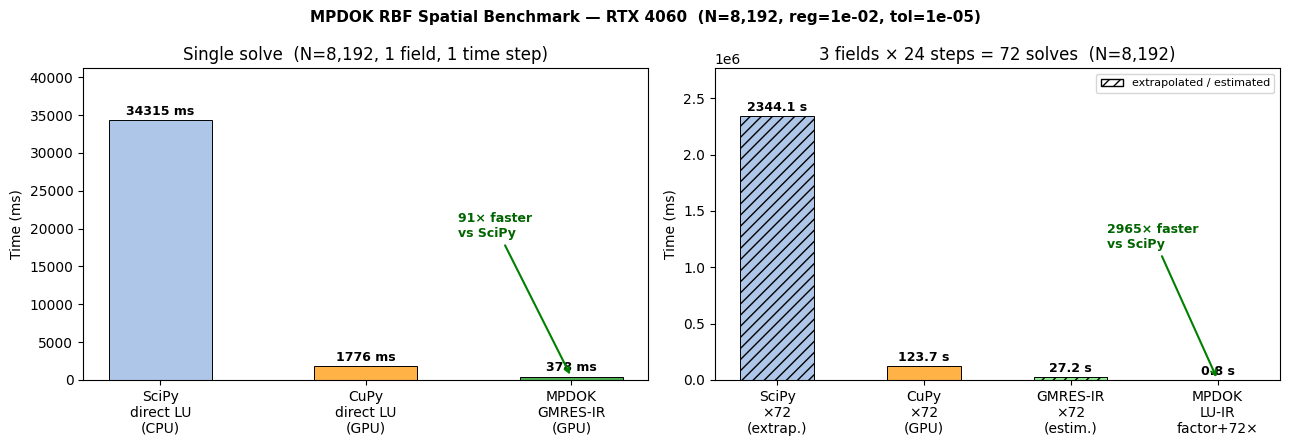

Saved: rbf_benchmark.png


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Left: single solve ────────────────────────────────────────────────
labels1 = ['SciPy\ndirect LU\n(CPU)', 'CuPy\ndirect LU\n(GPU)', 'MPDOK\nGMRES-IR\n(GPU)']
times1  = [t_scipy * 1e3, t_cupy * 1e3, t_gmres * 1e3]
colors1 = ['#aec6e8', '#ffb347', '#4caf50']
bars1   = axes[0].bar(labels1, times1, color=colors1, edgecolor='k', linewidth=0.7, width=0.5)
axes[0].set_ylabel('Time (ms)')
axes[0].set_title(f'Single solve  (N={N:,}, 1 field, 1 time step)')
for bar, t in zip(bars1, times1):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times1)*0.01,
                 f'{t:.0f} ms', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylim(0, max(times1) * 1.20)
axes[0].annotate(f'{t_scipy/t_gmres:.0f}× faster\nvs SciPy',
                 xy=(2, t_gmres*1e3), xytext=(1.45, max(times1)*0.55),
                 arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
                 fontsize=9, color='darkgreen', fontweight='bold')

# ── Right: 72-solve time series ───────────────────────────────────────
labels2 = ['SciPy\n×72\n(extrap.)', 'CuPy\n×72\n(GPU)', 'GMRES-IR\n×72\n(estim.)', 'MPDOK\nLU-IR\nfactor+72×']
times2  = [t_scipy72*1e3, t_cupy72*1e3, t_gmres72_est*1e3, t_lu72*1e3]
colors2 = ['#aec6e8', '#ffb347', '#90EE90', '#4caf50']
hatches = ['///', '', '///', '']
bars2   = axes[1].bar(labels2, times2, color=colors2, edgecolor='k', linewidth=0.7,
                      width=0.5, hatch=[h for h in hatches])
axes[1].set_ylabel('Time (ms)')
axes[1].set_title(f'3 fields × {T_STEPS} steps = {N_SOLVES} solves  (N={N:,})')
for bar, t in zip(bars2, times2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times2)*0.008,
                 f'{t/1e3:.1f} s', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_ylim(0, max(times2) * 1.18)
axes[1].annotate(f'{t_scipy72/t_lu72:.0f}× faster\nvs SciPy',
                 xy=(3, t_lu72*1e3), xytext=(2.25, max(times2)*0.5),
                 arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
                 fontsize=9, color='darkgreen', fontweight='bold')

# legend for hatching
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(facecolor='w', edgecolor='k', hatch='///', label='extrapolated / estimated')],
               loc='upper right', fontsize=8)

fig.suptitle(f'MPDOK RBF Spatial Benchmark — RTX 4060  (N={N:,}, reg={REG:.0e}, tol={TOL:.0e})',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('rbf_benchmark.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: rbf_benchmark.png")

---
## §6  Visualizing the Reconstructed Fields

The RBF weights $\mathbf{x}$ are not the field values — they are the expansion coefficients in the RBF basis. The reconstructed field at any point $p$ is:

$$f(p) = \sum_{i=1}^{N} x_i \, \exp\!\left(-\gamma\,\|p - p_i\|^2\right)$$

Below we evaluate this on a dense 150×150 grid to get a smooth map, then compare to the true analytical field and visualise all three fields at $t = 12$ (midday).

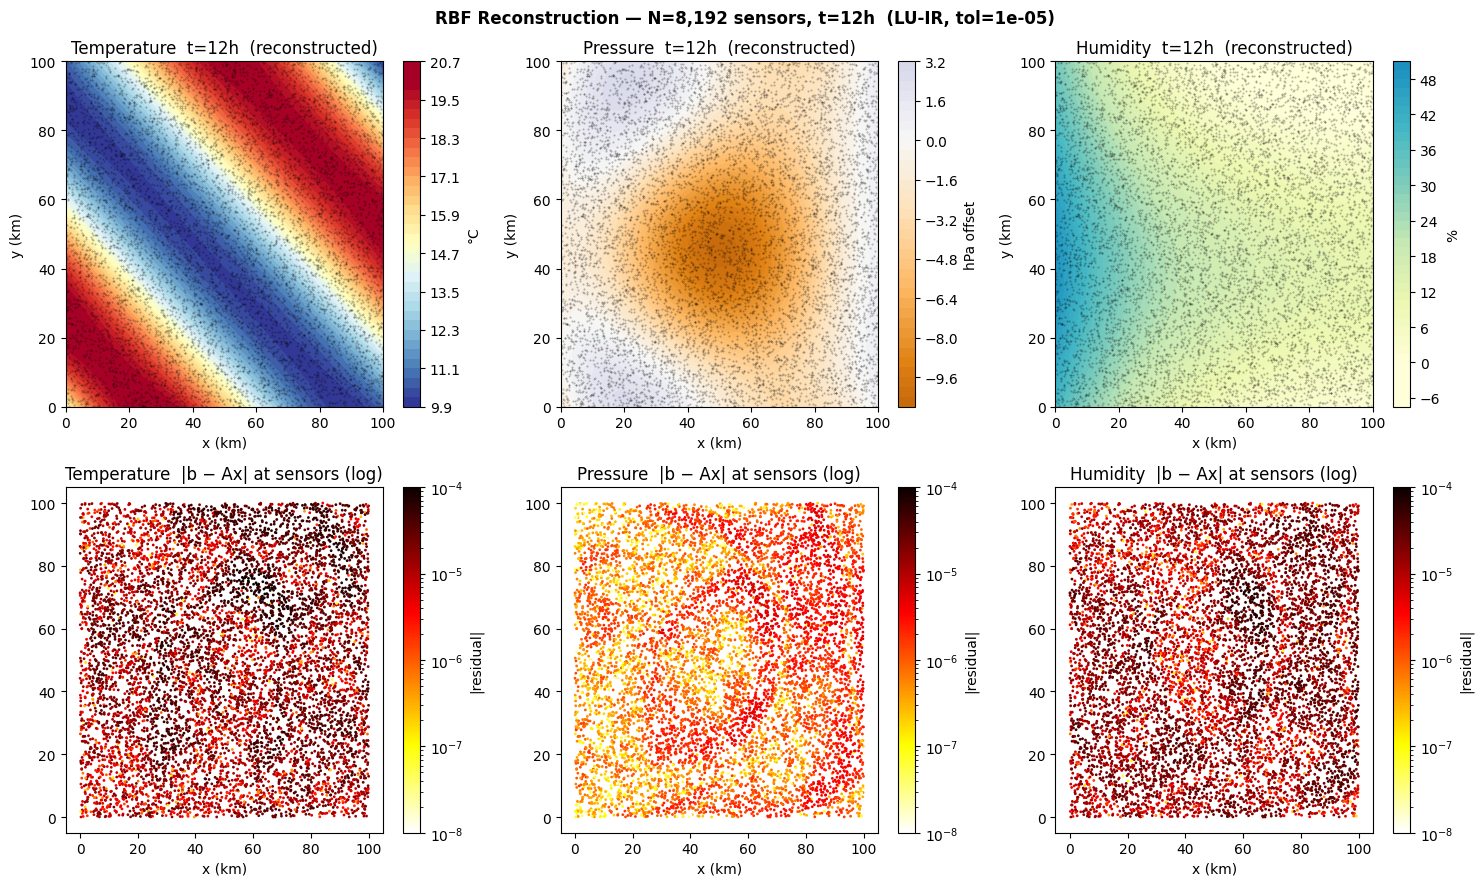

Saved: rbf_fields.png


In [10]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

GRID = 150
T_VIZ = 12   # midday snapshot

xi = cp.linspace(0, 100, GRID, dtype=cp.float64)
yi = cp.linspace(0, 100, GRID, dtype=cp.float64)
XX, YY = cp.meshgrid(xi, yi)
grid_pts = cp.stack([XX.ravel(), YY.ravel()], axis=1)   # (GRID^2, 2)

def rbf_eval_grid(grid_pts, sensor_coords, weights, gamma):
    """Evaluate sum_i w_i * exp(-gamma * ||p - p_i||^2) on grid_pts."""
    sq_grid    = cp.sum(grid_pts**2,    axis=1)   # (G,)
    sq_sensors = cp.sum(sensor_coords**2, axis=1) # (N,)
    # D2[g, i] = ||grid_g - sensor_i||^2
    D2 = sq_grid[:, None] + sq_sensors[None, :] - 2.0 * (grid_pts @ sensor_coords.T)
    cp.maximum(D2, 0.0, out=D2)
    K  = cp.exp(-gamma * D2)          # (G, N)
    return K @ weights                # (G,)

coords = net.coords

field_cfg = {
    'temperature': ('RdYlBu_r', (10, 20),  '°C'),
    'pressure':    ('PuOr',     (-15, 15), 'hPa offset'),
    'humidity':    ('YlGnBu',   (0,  80),  '%'),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col, (name, (cmap, (vlo, vhi), unit)) in enumerate(field_cfg.items()):
    b_t   = net.field(name, t=T_VIZ)
    x_t   = solver_lu.solve_factored(b_t, tol=TOL, maxiter_outer=3)
    cp.cuda.Stream.null.synchronize()

    recon = rbf_eval_grid(grid_pts, coords, x_t, gamma).reshape(GRID, GRID)
    recon_np = cp.asnumpy(recon)
    XX_np, YY_np = cp.asnumpy(XX), cp.asnumpy(YY)

    # Top row: reconstructed field
    im0 = axes[0, col].contourf(XX_np, YY_np, recon_np, levels=40, cmap=cmap,
                                 vmin=vlo, vmax=vhi)
    axes[0, col].scatter(cp.asnumpy(coords[:, 0]), cp.asnumpy(coords[:, 1]),
                         s=0.2, c='k', alpha=0.3)
    axes[0, col].set_title(f'{name.capitalize()}  t={T_VIZ}h  (reconstructed)')
    axes[0, col].set_xlabel('x (km)'); axes[0, col].set_ylabel('y (km)')
    plt.colorbar(im0, ax=axes[0, col], label=unit)

    # Bottom row: pointwise error at sensors
    b_np  = cp.asnumpy(b_t)
    b_rec = cp.asnumpy(A @ x_t)   # A @ x ≈ b (sensor predictions)
    err   = np.abs(b_np - b_rec)
    sc = axes[1, col].scatter(cp.asnumpy(coords[:, 0]), cp.asnumpy(coords[:, 1]),
                               c=err, s=1, cmap='hot_r',
                               norm=mcolors.LogNorm(vmin=1e-8, vmax=1e-4))
    axes[1, col].set_title(f'{name.capitalize()}  |b − Ax| at sensors (log)')
    axes[1, col].set_xlabel('x (km)')
    plt.colorbar(sc, ax=axes[1, col], label='|residual|')

fig.suptitle(f'RBF Reconstruction — N={N:,} sensors, t={T_VIZ}h  (LU-IR, tol={TOL:.0e})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('rbf_fields.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: rbf_fields.png")

solver_lu.free_factored()